# M1.Ex4: Modeling Non-linear Patterns

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex4_non-linear.ipynb)
- Raw Dataset: [bmi_and_life_expectancy.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv)

In [1]:
import pandas as pd
import sklearn

### Step 1. Load the data


In [2]:
# pd.read_csv("../../../datasets/bmi_and_life_expectancy.csv").head()

In [3]:
from pathlib import Path

possible_paths = [
    Path("bmi_and_life_expectancy.csv"),
    Path("student/exercises/week 3 exercises/bmi_and_life_expectancy.csv"),
    Path("python/student/exercises/week 3 exercises/bmi_and_life_expectancy.csv"),
]

for path in possible_paths:
    if path.exists():
        df = pd.read_csv(path)
        break
else:
    df = pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv")

df.head()

,Country,Life expectancy,BMI
0,Afghanistan,52.8,20.62058
1,Albania,76.8,26.44657
2,Algeria,75.5,24.59620
3,Andorra,84.6,27.63048
4,Angola,56.7,22.25083


### Step 2.a Assign variables `X` to the features and `y` to the target

In [4]:
X = df[["BMI"]]
y = df["Life expectancy"]

### Step 2.b print the type of each

In [5]:
print(X.dtypes)
print(y.dtype)

BMI    float64
dtype: object
float64


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

#### The target is numerical so its a regression task.


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [6]:
print("Data matrix (X):", X.shape)
print("Target (y):", y.shape)

Data matrix (X): (163, 1)
Target (y): (163,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [7]:
print("X summary:")
print(X.agg(["min", "max", "median", "mean", "std"]))

print("\ny summary:")
print(y.agg(["min", "max", "median", "mean", "std"]))

X summary:
              BMI
min     19.866920
max     30.995630
median  25.320540
mean    24.792378
std      2.427900

y summary:
min       44.500000
max       84.600000
median    71.800000
mean      69.666933
std        8.981933
Name: Life expectancy, dtype: float64


### Step 5. Plot the feature vs the target

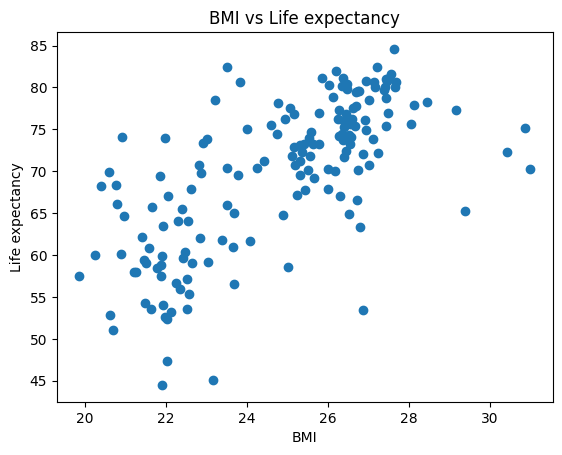

In [8]:
import matplotlib.pyplot as plt

plt.scatter(X["BMI"], y)
plt.xlabel("BMI")
plt.ylabel("Life expectancy")
plt.title("BMI vs Life expectancy")
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

#### The relationship is generally increasing, but it is not perfectly linear as there are some outliers and the points are not perfectly aligned.

### Step 7. Make two modeling techniques

First model is just a Linear Regression model: `from sklearn.linear_model import LinearRegression`

Second model: Use one of the previously mentioned methods to model a non-linear relationship

1. `from sklearn.tree import DecisionTreeRegressor`
2. or `from sklearn.preprocessing import PolynomialFeatures`

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

linear_model = LinearRegression()
tree_model = DecisionTreeRegressor(max_depth=4, random_state=42)

### Step 8. Split the dataset into train and test sets

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Step 9. Train both models on the training set

In [11]:
linear_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

### Step 10. Evaluate and compare which of the two models score better on the `train` set

In [12]:
linear_train_score = linear_model.score(X_train, y_train)
tree_train_score = tree_model.score(X_train, y_train)

print("Linear Regression train score:", linear_train_score)
print("Decision Tree train score:", tree_train_score)

Linear Regression train score: 0.4939543914188669
Decision Tree train score: 0.7191725993373643


### Step 11. Evaluate and compare which of the two models score better on the `test` set

In [13]:
linear_test_score = linear_model.score(X_test, y_test)
tree_test_score = tree_model.score(X_test, y_test)

print("Linear Regression test score:", linear_test_score)
print("Decision Tree test score:", tree_test_score)

if tree_test_score > linear_test_score:
    print("The Decision Tree model performs better on the test set.")
else:
    print("The Linear Regression model performs better on the test set.")

Linear Regression test score: 0.354031336152445
Decision Tree test score: 0.4442430869770534
The Decision Tree model performs better on the test set.
